# Introduction

## Purpose

The purpose of this notebook is to explore electricity prices in Sweden. The analysis explores different patterns over time and looks for correlations between different features. For instance, does the weather have any affect on the spot prices?

## Dataset overview

This notebook uses hourly electricity price and weather data for Sweden's four electricity zones: SE1, SE2, SE3 and SE4.
The dataset contains historical data from weather and electricity spot prices, and this EDA was made on observations starting from 2025-01-01 all the way to present day.


# Imports

In [148]:
import sys

# Allow the notebook to import modules from the project root.
sys.path.append("..")

from backend.app.ml.preprocessing import prepare_data
import backend.app.ml.preprocessing as preprocessing
import importlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
# Load the raw dataset.
df = pd.read_csv("../dataset/all_zones_complete.csv")

df.head()

,timestamp,temp_se1_c,wind_se1_kmh,rain_se1_mm,temp_se2_c,wind_se2_kmh,rain_se2_mm,temp_se3_c,wind_se3_kmh,rain_se3_mm,...,rain_se4_mm,price_se1_eur_mwh,price_se2_eur_mwh,price_se3_eur_mwh,price_se4_eur_mwh,timestamp_local,hour,day_of_week,month,is_weekend
0,2025-01-01 00:00:00+00:00,-9.1,8.6,0.0,-13.1,3.2,0.0,-0.6,18.4,0.0,...,0.9,3.97,3.69,2.47,2.04,2025-01-01 01:00:00,1,2,1,0
1,2025-01-01 01:00:00+00:00,-11.6,9.2,0.0,-13.4,5.5,0.0,0.2,12.7,0.0,...,0.3,3.82,3.55,2.44,2.04,2025-01-01 02:00:00,2,2,1,0
2,2025-01-01 02:00:00+00:00,-12.2,8.3,0.0,-14.6,6.6,0.0,0.6,5.2,0.1,...,0.7,3.49,3.19,1.98,1.54,2025-01-01 03:00:00,3,2,1,0
3,2025-01-01 03:00:00+00:00,-12.5,7.3,0.0,-14.3,7.5,0.0,1.2,6.5,0.1,...,0.9,3.46,3.15,1.79,1.18,2025-01-01 04:00:00,4,2,1,0
4,2025-01-01 04:00:00+00:00,-12.6,5.7,0.0,-14.5,8.8,0.0,1.5,7.6,0.1,...,0.7,3.89,3.68,2.71,2.38,2025-01-01 05:00:00,5,2,1,0


In [185]:

importlib.reload(preprocessing)

<module 'backend.app.ml.preprocessing' from 'c:\\Users\\cecil\\python\\ai-ml\\Predictor\\backend\\app\\ml\\preprocessing.py'>

In [186]:
# Apply the project's preprocessing steps and check for missing values.
df_prepared = preprocessing.prepare_data(df)

print(df_prepared.shape)
print(df_prepared["zone"].value_counts())

(60456, 14)
zone
SE1    15114
SE2    15114
SE3    15114
SE4    15114
Name: count, dtype: int64


In [187]:
df_prepared.isna().sum()

timestamp               0
timestamp_local         0
temperature_c           0
wind_speed_kmh          0
rain_mm                 0
spot_price_eur_mwh      0
zone                    0
hour                    0
day_of_week             0
month                   0
is_weekend              0
price_lag_24           96
price_lag_48          192
price_lag_168         672
dtype: int64

In [188]:
df_prepared.columns.tolist()

['timestamp',
 'timestamp_local',
 'temperature_c',
 'wind_speed_kmh',
 'rain_mm',
 'spot_price_eur_mwh',
 'zone',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'price_lag_24',
 'price_lag_48',
 'price_lag_168']

In [189]:
df_prepared.info()

<class 'pandas.DataFrame'>
RangeIndex: 60456 entries, 0 to 60455
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype                           
---  ------              --------------  -----                           
 0   timestamp           60456 non-null  datetime64[us, UTC]             
 1   timestamp_local     60456 non-null  datetime64[us, Europe/Stockholm]
 2   temperature_c       60456 non-null  float64                         
 3   wind_speed_kmh      60456 non-null  float64                         
 4   rain_mm             60456 non-null  float64                         
 5   spot_price_eur_mwh  60456 non-null  float64                         
 6   zone                60456 non-null  str                             
 7   hour                60456 non-null  int32                           
 8   day_of_week         60456 non-null  int32                           
 9   month               60456 non-null  int32                           
 10  is_weeken

The missing values in the lagged price features occur at the beginning of the dataset, where previous observations are not available. These rows should be handled before model training.

In [190]:
df_prepared[["timestamp", "timestamp_local"]].head()

,timestamp,timestamp_local
0,2025-01-01 00:00:00+00:00,2025-01-01 02:00:00+01:00
1,2025-01-01 01:00:00+00:00,2025-01-01 03:00:00+01:00
2,2025-01-01 02:00:00+00:00,2025-01-01 04:00:00+01:00
3,2025-01-01 03:00:00+00:00,2025-01-01 05:00:00+01:00
4,2025-01-01 04:00:00+00:00,2025-01-01 06:00:00+01:00


In [191]:
df_prepared[["timestamp", "timestamp_local"]].dtypes

timestamp                       datetime64[us, UTC]
timestamp_local    datetime64[us, Europe/Stockholm]
dtype: object

In [193]:
print(
    "Chronologically sorted:",
    df["timestamp"].is_monotonic_increasing
)

Chronologically sorted: True


In [194]:
df_prepared.duplicated(
    subset=["zone", "timestamp"]
).sum()

np.int64(0)

In [195]:
df_prepared.groupby("zone")["timestamp"].apply(
    lambda x: x.is_monotonic_increasing
)

zone
SE1    True
SE2    True
SE3    True
SE4    True
Name: timestamp, dtype: bool

In [196]:
time_diff = (
    df_prepared
    .groupby("zone")["timestamp"]
    .diff()
)

time_diff.value_counts()

timestamp
0 days 01:00:00    60444
0 days 03:00:00        8
Name: count, dtype: int64

In [197]:
# Add yesterday's price at the same hour as a forecasting feature.
df_prepared[
    [
        "zone",
        "timestamp_local",
        "spot_price_eur_mwh",
        "price_lag_24"
    ]
].head(30)

,zone,timestamp_local,spot_price_eur_mwh,price_lag_24
0,SE1,2025-01-01 02:00:00+01:00,3.97,NaN
1,SE1,2025-01-01 03:00:00+01:00,3.82,NaN
2,SE1,2025-01-01 04:00:00+01:00,3.49,NaN
3,SE1,2025-01-01 05:00:00+01:00,3.46,NaN
4,SE1,2025-01-01 06:00:00+01:00,3.89,NaN
5,SE1,2025-01-01 07:00:00+01:00,3.54,NaN
6,SE1,2025-01-01 08:00:00+01:00,3.83,NaN
7,SE1,2025-01-01 09:00:00+01:00,4.67,NaN
8,SE1,2025-01-01 10:00:00+01:00,5.15,NaN
9,SE1,2025-01-01 11:00:00+01:00,6.04,NaN


# Exploratory Data Analysis

In [198]:
df_prepared["spot_price_eur_mwh"].describe()

count    60456.000000
mean        46.320788
std         49.209395
min        -92.880000
25%          5.920000
50%         29.600000
75%         75.612500
max        739.360000
Name: spot_price_eur_mwh, dtype: float64

In [199]:
df_prepared.groupby("zone")["spot_price_eur_mwh"].describe()

,count,mean,std,min,25%,50%,75%,max
zone,,,,,,,,
SE1,15114.0,28.416272,38.801238,-92.88,4.260,10.995,36.0450,380.06
SE2,15114.0,28.765614,39.471149,-25.22,3.630,10.395,38.0000,425.27
SE3,15114.0,56.439290,46.589096,-25.05,21.945,45.650,85.2800,485.72
SE4,15114.0,71.661977,55.491267,-25.30,28.085,65.985,105.6275,739.36


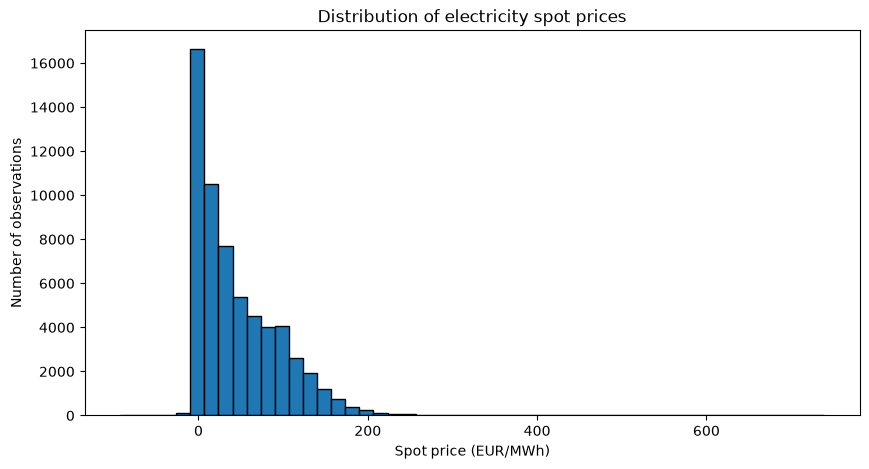

In [200]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_prepared["spot_price_eur_mwh"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Spot price (EUR/MWh)")
plt.ylabel("Number of observations")
plt.title("Distribution of electricity spot prices")

plt.show()

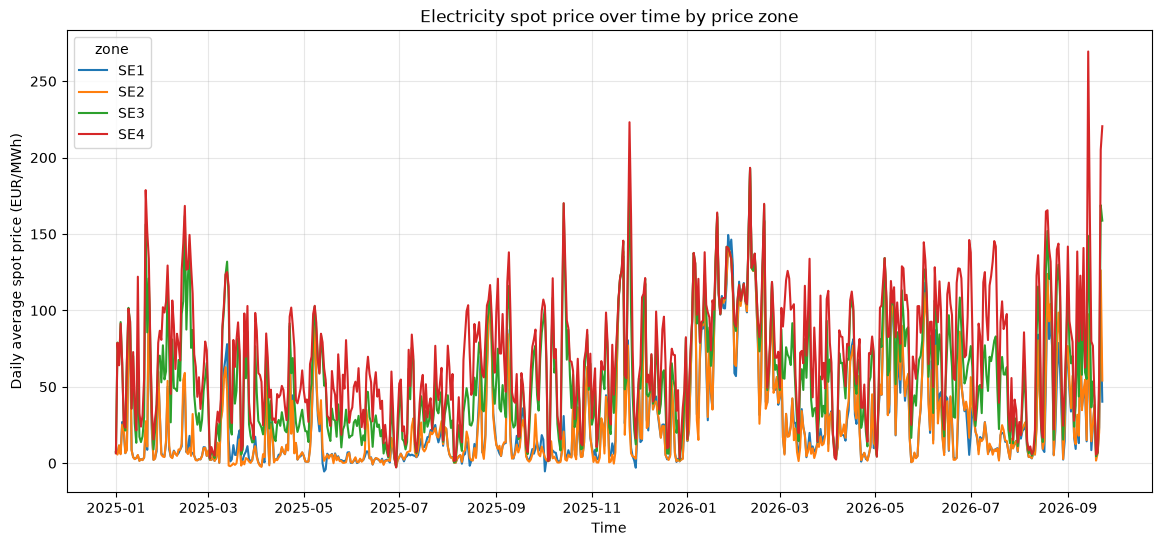

In [201]:
# Calculate daily average electricity price for each price zone.
daily_prices = (
    df_prepared
    .set_index("timestamp_local")
    .groupby("zone")["spot_price_eur_mwh"]
    .resample("D")
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_prices,
    x="timestamp_local",
    y="spot_price_eur_mwh",
    hue="zone"
)

plt.xlabel("Time")
plt.ylabel("Daily average spot price (EUR/MWh)")
plt.title("Electricity spot price over time by price zone")
plt.grid(alpha=0.3)
plt.show()

In [202]:
print("Negative prices:", (df_prepared["spot_price_eur_mwh"] < 0).sum())
print("Zero prices:", (df_prepared["spot_price_eur_mwh"] == 0).sum())
print("Prices above 100 EUR/MWh:", (df_prepared["spot_price_eur_mwh"] > 100).sum())
print("Prices above 200 EUR/MWh:", (df_prepared["spot_price_eur_mwh"] > 200).sum())

Negative prices: 2214
Zero prices: 174
Prices above 100 EUR/MWh: 9190
Prices above 200 EUR/MWh: 511


In [203]:
price_extremes = df_prepared.groupby("zone")["spot_price_eur_mwh"].agg(
    negative=lambda x: (x < 0).sum(),
    zero=lambda x: (x == 0).sum(),
    above_100=lambda x: (x > 100).sum(),
    above_200=lambda x: (x > 200).sum()
)

price_extremes

,negative,zero,above_100,above_200
zone,,,,
SE1,574,44,1117,46
SE2,767,71,1153,48
SE3,417,37,2601,132
SE4,456,22,4319,285


### Initial observations

Prices range from -25.05 to 485.72 EUR/MWh. The mean price is higher than the median, which suggests that occasional high prices pull the distribution to the right.

Negative prices and price spikes are kept because they are important for forecasting.

In [204]:
weather_features = [
    "temperature_c",
    "wind_speed_kmh",
    "rain_mm"
]

df_prepared[weather_features].describe()

,temperature_c,wind_speed_kmh,rain_mm
count,60456.000000,60456.000000,60456.000000
mean,7.189978,13.504194,0.071505
std,9.254393,6.973094,0.356097
min,-31.950001,0.000000,0.000000
25%,1.500000,8.390780,0.000000
50%,7.900000,12.749540,0.000000
75%,14.200000,17.800000,0.000000
max,30.400000,52.900000,22.900000


In [205]:
# Measure linear relationships between weather variables and electricity price.
correlations = df_prepared[
    [
        "temperature_c",
        "wind_speed_kmh",
        "rain_mm",
        "spot_price_eur_mwh"
    ]
].corr()

correlations

,temperature_c,wind_speed_kmh,rain_mm,spot_price_eur_mwh
temperature_c,1.000000,0.078057,0.079076,-0.173208
wind_speed_kmh,0.078057,1.000000,0.082665,-0.204773
rain_mm,0.079076,0.082665,1.000000,-0.062012
spot_price_eur_mwh,-0.173208,-0.204773,-0.062012,1.000000


In [206]:
correlations["spot_price_eur_mwh"].sort_values(
    ascending=False
)

spot_price_eur_mwh    1.000000
rain_mm              -0.062012
temperature_c        -0.173208
wind_speed_kmh       -0.204773
Name: spot_price_eur_mwh, dtype: float64

### Correlation observations

Higher temperatures and stronger wind are generally linked to lower prices. Rain has almost no linear relationship with price.

Correlation does not show cause and effect. These features may still help a Random Forest model.

In [207]:
# Check the time-based features created during preprocessing.
df_prepared[
    ["timestamp_local", "hour", "day_of_week", "month", "is_weekend"]
].head()

,timestamp_local,hour,day_of_week,month,is_weekend
0,2025-01-01 02:00:00+01:00,2,2,1,0
1,2025-01-01 03:00:00+01:00,3,2,1,0
2,2025-01-01 04:00:00+01:00,4,2,1,0
3,2025-01-01 05:00:00+01:00,5,2,1,0
4,2025-01-01 06:00:00+01:00,6,2,1,0


In [208]:
# Calculate average hourly electricity prices for each price zone.
hourly_prices = (
    df_prepared
    .groupby(["zone", "hour"])["spot_price_eur_mwh"]
    .mean()
    .reset_index()
)

hourly_prices

,zone,hour,spot_price_eur_mwh
0,SE1,0,27.391968
1,SE1,1,23.834127
2,SE1,2,21.734051
3,SE1,3,20.263700
4,SE1,4,19.665211
...,...,...,...
91,SE4,19,80.154615
92,SE4,20,93.437294
93,SE4,21,105.533933
94,SE4,22,105.583095


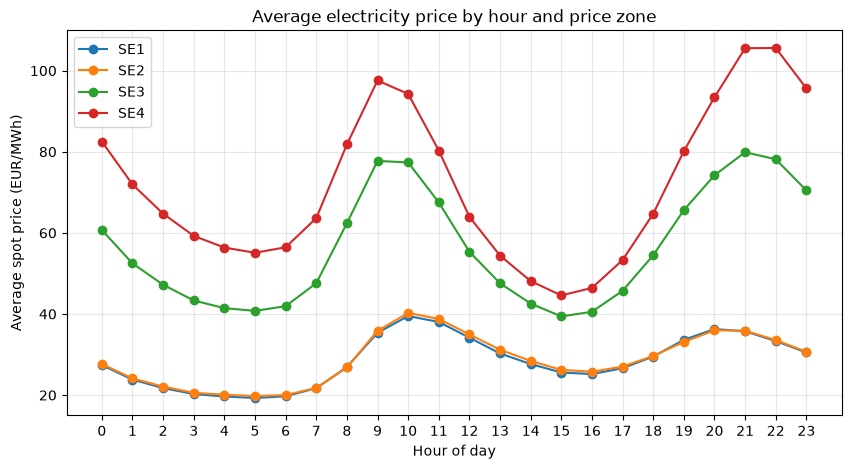

In [209]:
plt.figure(figsize=(10, 5))

for zone in hourly_prices["zone"].unique():
    zone_data = hourly_prices[hourly_prices["zone"] == zone]

    plt.plot(
        zone_data["hour"],
        zone_data["spot_price_eur_mwh"],
        marker="o",
        label=zone
    )

plt.xticks(range(24))

plt.xlabel("Hour of day")
plt.ylabel("Average spot price (EUR/MWh)")
plt.title("Average electricity price by hour and price zone")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [210]:
# Calculate average electricity prices by weekday for each price zone.
weekday_prices = (
    df_prepared
    .groupby(["zone", "day_of_week"])["spot_price_eur_mwh"]
    .mean()
    .reset_index()
)

weekday_prices

,zone,day_of_week,spot_price_eur_mwh
0,SE1,0,31.838490
1,SE1,1,34.731840
2,SE1,2,31.913459
3,SE1,3,33.269091
4,SE1,4,30.414918
5,SE1,5,18.621227
6,SE1,6,18.112120
7,SE2,0,32.575591
8,SE2,1,35.567815
9,SE2,2,32.659868


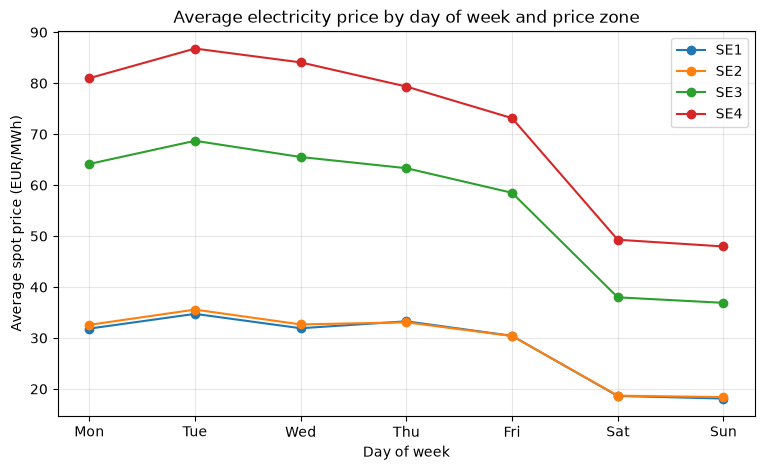

In [211]:
weekday_names = [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun"
]

plt.figure(figsize=(9, 5))

for zone in weekday_prices["zone"].unique():
    zone_data = weekday_prices[weekday_prices["zone"] == zone]

    plt.plot(
        zone_data["day_of_week"],
        zone_data["spot_price_eur_mwh"],
        marker="o",
        label=zone
    )

plt.xticks(
    range(7),
    weekday_names
)

plt.xlabel("Day of week")
plt.ylabel("Average spot price (EUR/MWh)")
plt.title("Average electricity price by day of week and price zone")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Time-based patterns

Prices are usually lowest at night and in the early afternoon. They often peak in the morning and evening.

Weekend prices are lower than weekday prices. Hour, day of week, and weekend status may help the model.

In [212]:
# Summarize monthly electricity prices for each price zone.
monthly_prices = (
    df_prepared
    .groupby(["zone", "month"])["spot_price_eur_mwh"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

monthly_prices

,zone,month,mean,median,std,count
0,SE1,1,54.365673,32.025,53.617705,1486
1,SE1,2,52.196176,27.840,56.143925,1344
2,SE1,3,17.845916,11.040,21.624026,1484
3,SE1,4,18.732104,7.100,28.492531,1440
4,SE1,5,29.771767,9.730,37.997256,1488
5,SE1,6,22.429319,5.000,34.051691,1440
6,SE1,7,13.246505,10.675,10.059498,1488
7,SE1,8,28.264200,10.230,37.110507,1488
8,SE1,9,24.944657,12.645,32.244920,1246
9,SE1,10,12.957962,5.480,18.760003,746


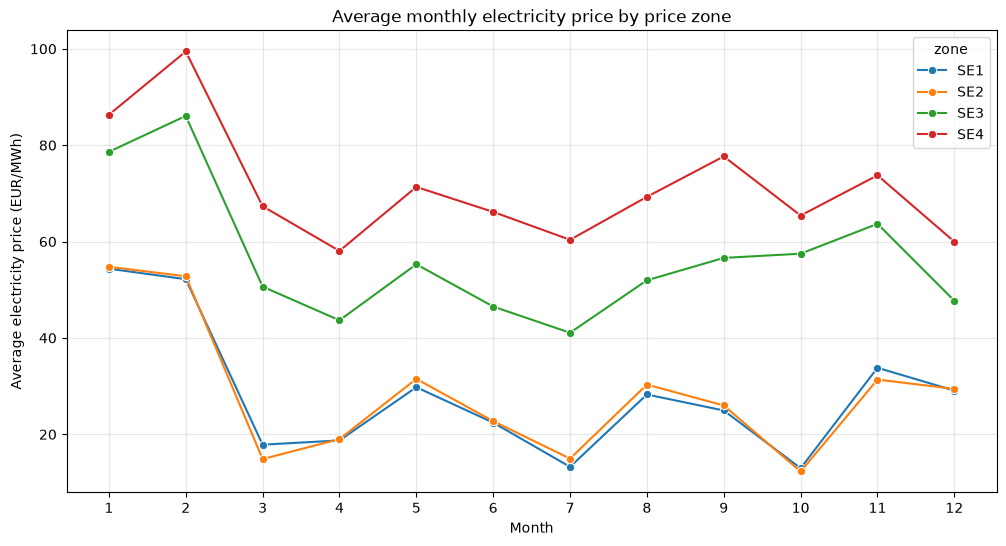

In [213]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_prices,
    x="month",
    y="mean",
    hue="zone",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title("Average monthly electricity price by price zone")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()

### Monthly price patterns

Monthly electricity prices differ clearly between the price zones. SE1 and SE2 generally have lower average prices, while SE3 and especially SE4 have higher prices throughout the year. February has the highest average price in all zones.

The mean is often higher than the median, indicating that occasional price spikes increase the average. The relatively high standard deviations also show that prices vary considerably within several months. These monthly and zone-specific patterns may provide useful information for price prediction.

## Summary

The EDA shows that electricity prices vary between price zones over time. The overall pattern is similar across the price zones, although the price levels vary between zones. Prices are generally higher during morning and evening hours, while weekend and nighttime often have lower prices. The dataset also contains negative prices and occasional price spikes, which are important for forecasting.

The analysis shows that temperature and wind speed are associated with electricity prices, while rainfall has a weaker linear relationship. These variables may therefore be useful as features in the prediction models.

Important to notice is that the analysis describes patterns and correlations, but it does not prove casual relationships.